In [1650]:
import numpy as np
import random
import matplotlib.pyplot  as plt
import scipy.stats as sci
from math import exp
from scipy.special import comb

In [1651]:
count = 25

In [1652]:
def bootstrap(n, sample):
    bootstrap_sample = []
    for _ in range (n):
        idx = np.random.randint(0, len(sample), len(sample))
        bootstrap_sample.append(sample[idx])
    return np.array(bootstrap_sample)

### Генерация выборки

In [1653]:
sample = np.array([random.expovariate(1) for _ in range (count)])

print(f'Выборка: {sample}')

Выборка: [1.85781624e+00 6.81570136e-01 6.47116499e-01 3.99039007e-01
 3.76551801e-04 3.68920762e+00 1.32051333e-01 1.67713708e+00
 3.93591058e-01 2.78174028e-01 3.23257431e+00 5.02340876e+00
 2.10859012e+00 6.93023708e-01 8.70359954e-02 1.75262482e+00
 5.60554358e-01 9.53863739e-02 1.48021419e+00 2.09155470e-01
 2.00777630e-01 9.81714834e-01 1.22391921e+00 7.46659827e-01
 2.67556789e-01]


### а)

In [1654]:
unique_elems = np.unique_counts(sample)

if np.max(unique_elems.counts) == 1:
    print (f'Мода: все элементы')
else:
    print(f'Мода: {unique_elems.values[unique_elems.counts.argmax()]}')


mu3 = np.mean((sample - np.mean(sample))**3)
mu2 = np.mean((sample - np.mean(sample))**2)
print (f'Коэфициент ассиметрии: {mu3/(mu2**(3/2))}')

print(f'Медиана: {np.sort(sample)[13]}')
print(f'Размах: {sample.max() - sample.min()}')

Мода: все элементы
Коэфициент ассиметрии: 1.632991520620384
Медиана: 0.6930237075595647
Размах: 5.023032207939461


### b)

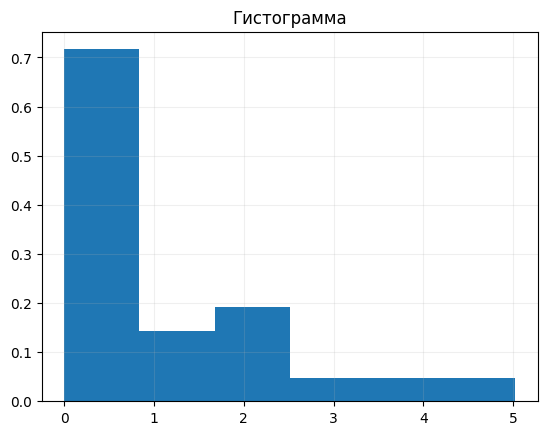

In [1655]:
plt.hist(sample, density=True, bins='sturges')

plt.grid(alpha=0.2)
plt.title('Гистограмма')
plt.show()

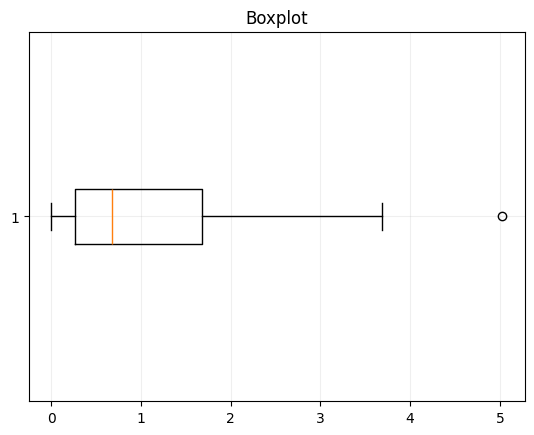

In [1656]:
plt.boxplot(sample, vert=False)

plt.grid(alpha=0.2)
plt.title('Boxplot')
plt.show()

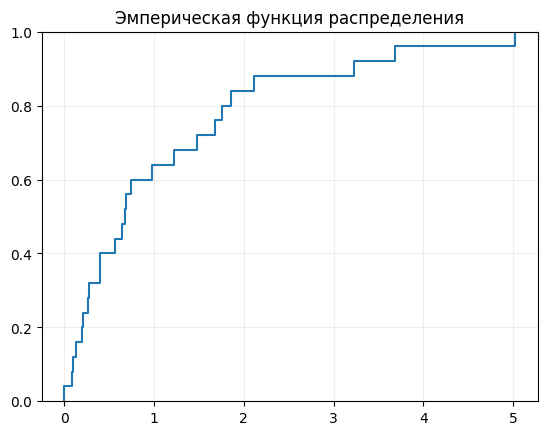

In [1657]:
plt.ecdf(sample)

plt.grid(alpha=0.2)
plt.title('Эмперическая функция распределения')

plt.show()

### c)

In [1658]:
bootstrap_samples = bootstrap(100000, sample)

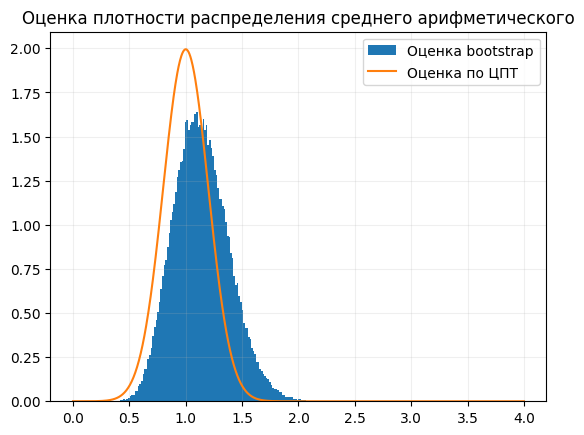

In [1663]:
bootstrap_mean = np.mean(bootstrap_samples, axis=1)

plt.hist(bootstrap_mean, bins='auto', density=True, label='Оценка bootstrap')

x = np.linspace(0, 4, 1000)
y = sci.norm.pdf(x, loc=1, scale=1/5)

plt.plot(x, y, label='Оценка по ЦПТ')

plt.legend()
plt.grid(alpha=0.2)
plt.title('Оценка плотности распределения среднего арифметического')
plt.show()


### d)

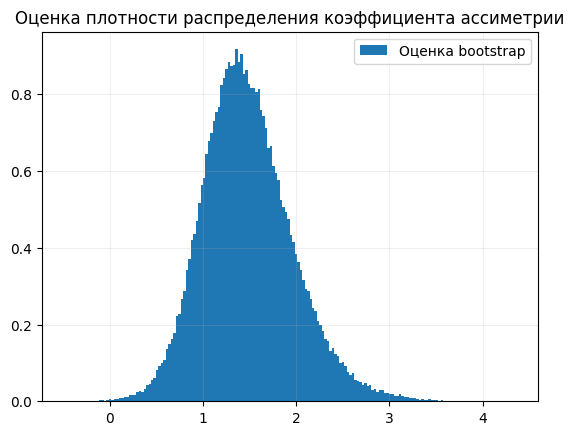

In [1660]:
asymmetry_coeff = sci.skew(bootstrap_samples, axis=1)

plt.hist(asymmetry_coeff, bins='auto', density=True, label='Оценка bootstrap')

plt.grid(alpha=0.2)
plt.legend()
plt.title('Оценка плотности распределения коэффициента ассиметрии')
plt.show()

In [1661]:
hist, bins = np.histogram(asymmetry_coeff, bins='auto', density=True)
dx = np.diff(bins)

integration_mask = bins[:-1] < 1

print (f'Вероятность коэффициент ассиметрии < 1 = {np.sum(hist[integration_mask] * dx[integration_mask])}') 

Вероятность коэффициент ассиметрии < 1 = 0.14784999999999998


### e)

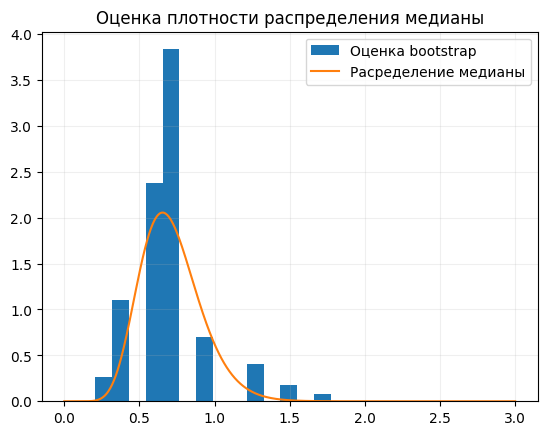

In [1662]:
mediana = np.median(bootstrap_samples, axis=1)

plt.hist(mediana, bins='sturges', density=True, label='Оценка bootstrap')

x = np.linspace(0, 3, 1000)
i = np.arange(13,26)
y = np.sum(
    comb(25, i)[:, None] * (
        i[:, None] * (1 - np.exp(-x))[None, :]**(i[:, None] - 1)
        * np.exp(-x)[None, :] * np.exp(-x)[None, :]**(25 - i[:, None])
        -
        (25 - i)[:, None] * (1 - np.exp(-x))[None, :]**i[:, None]
        * np.exp(-x)[None, :]**(24 - i[:, None]) * np.exp(-x)[None, :]
    ),
    axis=0
)

plt.plot(x, y, label='Расределение медианы')

plt.legend()
plt.grid(alpha=0.2)
plt.title('Оценка плотности распределения медианы')
plt.show()